In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import ruptures as rpt

In [2]:
data = pd.read_csv("../data/processed_data/1_datacenter.csv")
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index("timestamp",inplace=True) 

In [8]:
# change point detection

change_points = []

chunk_size=500
model = "rbf"

for i in range(0, len(data), chunk_size):
    chunk = data.iloc[i:i + chunk_size]
    signal = chunk['gpu0_util'].to_numpy()
    algo = rpt.Pelt(model=model).fit(signal)
    result = algo.predict(pen=2) 
    change_points.append(result)

In [9]:
len(change_points)

173

In [ ]:
# 重新组织索引，最后一个点可以丢掉，因为无论是否变化都会加上最后一个时刻。
global_len = 0
ground_points = []

for r in change_points:
    if len(r) == 1:
        '''
        No change point in the subsequence
        '''
        global_len += chunk_size
    else:
        '''
        delete the last point, and increase the index by chunk size
        '''
        ground_points += list(map(lambda x: x + global_len, r))[:-1]
        global_len += chunk_size

In [16]:
len(ground_points)

211

总共211个改变点，好少呀。   
check下，是否存在问题。 
方法：通过打印改变点附近的数值

In [18]:
data['gpu0_util'].iloc[ground_points[0]-5: ground_points[0]+5]

timestamp
2025-07-30 12:24:30    0.00
2025-07-30 12:25:00    0.00
2025-07-30 12:25:30    0.02
2025-07-30 12:26:00    0.68
2025-07-30 12:26:30    1.00
2025-07-30 12:27:00    0.70
2025-07-30 12:27:30    1.00
2025-07-30 12:28:00    1.00
2025-07-30 12:28:30    0.80
2025-07-30 12:29:00    1.00
Name: gpu0_util, dtype: float64

In [ ]:
data['gpu0_util'].iloc[ground_points[0]]

0.7

上面探测来看，识别错误了2个位置。

In [20]:
data['gpu0_util'].iloc[ground_points[1]]

0.0

In [21]:
data['gpu0_util'].iloc[ground_points[1]-5: ground_points[1]+5]

timestamp
2025-07-30 15:09:30    1.00
2025-07-30 15:10:00    0.98
2025-07-30 15:10:30    0.77
2025-07-30 15:11:00    1.00
2025-07-30 15:11:30    0.00
2025-07-30 15:12:00    0.00
2025-07-30 15:12:30    0.00
2025-07-30 15:13:00    0.00
2025-07-30 15:13:30    0.00
2025-07-30 15:14:00    0.00
Name: gpu0_util, dtype: float64

In [ ]:
print(data['gpu0_util'].iloc[ground_points[2]])
data['gpu0_util'].iloc[ground_points[2]-5: ground_points[2]+5]

0.0


timestamp
2025-07-31 01:22:00    1.00
2025-07-31 01:22:30    1.00
2025-07-31 01:23:00    0.00
2025-07-31 01:23:30    0.00
2025-07-31 01:24:00    0.00
2025-07-31 01:24:30    0.00
2025-07-31 01:25:00    1.00
2025-07-31 01:25:30    0.98
2025-07-31 01:26:00    0.98
2025-07-31 01:26:30    1.00
Name: gpu0_util, dtype: float64

In [14]:
xxx = [1,3,4,5]
xxx += [2,3]
print(xxx)

[1, 3, 4, 5, 2, 3]


In [24]:
# sample = data.loc["2025-07-30 12:00:00": "2025-08-02 17:00:00"]
# signal = sample['gpu0_util'].to_numpy()
# model = "rbf"
# algo = rpt.Pelt(model=model).fit(signal)
# result = algo.predict(pen=2)  # pen 是惩罚项大小，影响分段数量

# # 3. 可视化
# rpt.display(signal, result, figsize=(10, 6))
# plt.title("Change Point Detection with PELT")
# plt.show()

根据前面的分析来看，改变点有错位，需要进一步修订。

这也带来了一个问题，是否直接通过shift错位计算相邻差值，直接阈值判断，识别改变点？

In [25]:
diff_gpu = data['gpu0_util'].diff()
points = diff_gpu.abs() > 0.7 # threshold

points = points[points].index.tolist()


In [26]:
len(points)

984

In [27]:
points[0]

Timestamp('2025-07-30 15:11:30')

<Axes: xlabel='timestamp'>

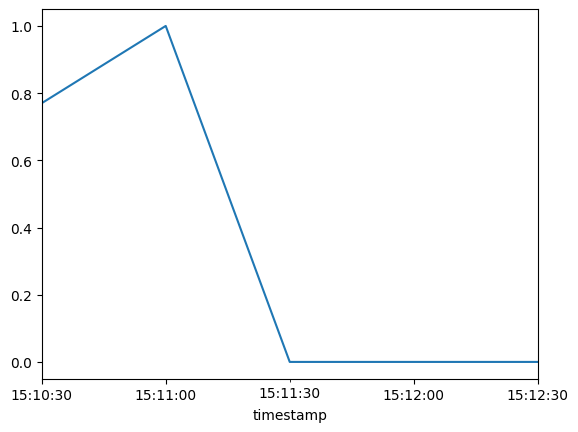

In [ ]:
sample = data.loc["2025-07-30 15:10:30":"2025-07-30 15:12:30"]

sample['gpu0_util'].plot()

In [29]:
points[1]

Timestamp('2025-07-31 01:22:00')

<Axes: xlabel='timestamp'>

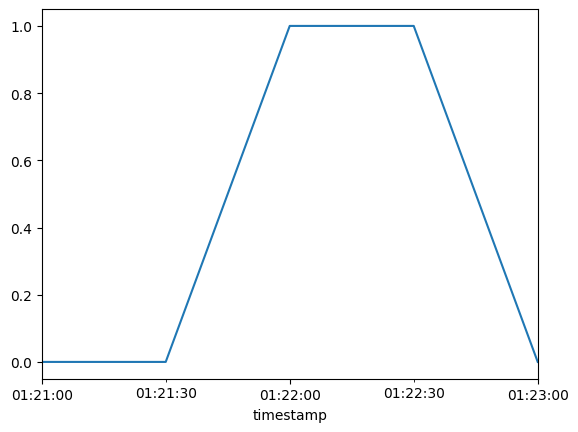

In [30]:
sample = data.loc["2025-07-31 01:21:00":"2025-07-31 01:23:00"]

sample['gpu0_util'].plot()

In [31]:
points[2]

Timestamp('2025-07-31 01:23:00')

保存GPU事件变化数据集